In [77]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling


In [19]:
#tf.keras.utils.image_dataset_from_directory??

In [78]:
trainData = tf.keras.utils.image_dataset_from_directory(
    'trainData',
    image_size = (224,224),
    batch_size = 32)
#### Uncomment below after valData is uploaded
valData = tf.keras.utils.image_dataset_from_directory(
    'valData',
    image_size = (224,224),
    batch_size = 32)


Found 11332 files belonging to 3 classes.
Found 5702 files belonging to 3 classes.


In [79]:
trainData = trainData.map(lambda x, y: (x/255, y))
valData = valData.map(lambda x,y: (x/255, y))


In [80]:
# Rerun this to get a new batch
data_iterator = trainData.as_numpy_iterator()
batch = data_iterator.next()
batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 224, 224, 3)

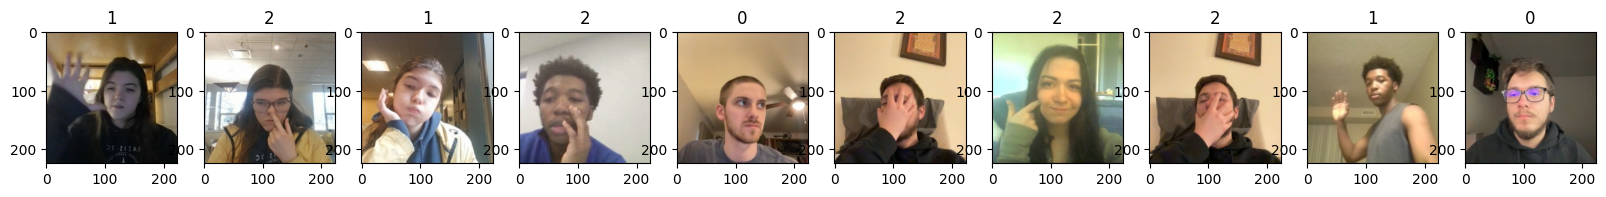

In [81]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [82]:
# Rerun this to get a new batch
val_data_iterator = valData.as_numpy_iterator()
val_batch = val_data_iterator.next()
val_batch[0].shape
##batch[0]-->contains images
##batch[1]-->contains labels

(32, 224, 224, 3)

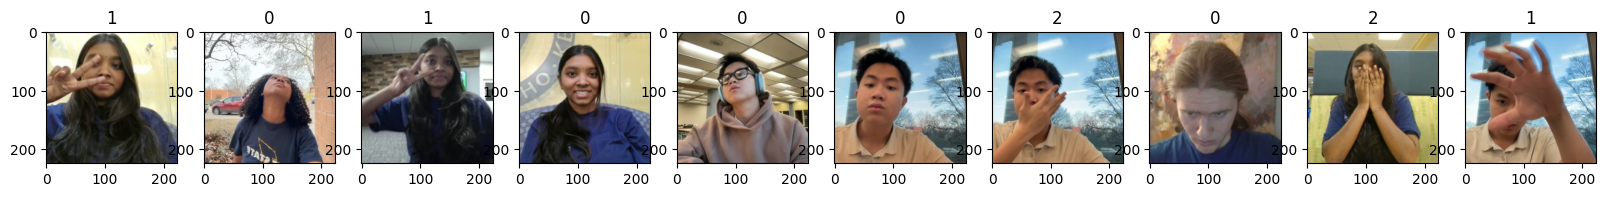

In [83]:
#####      This is for training data     #############
# noHands = 0
# noTouchHands = 1
# touch = 2
fig, ax = plt.subplots(ncols = 10, figsize = (20,20))
for idx, img in enumerate(val_batch[0][:10]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(val_batch[1][idx])

In [84]:
cnn = Sequential()

In [85]:
cnn.add(RandomFlip("horizontal"))
cnn.add(RandomRotation(0.05))
cnn.add(RandomZoom(0.05))

# Block 1
cnn.add(Conv2D(32,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

# Block 2
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

# Block 3
cnn.add(Conv2D(128,(3,3),activation='relu'))
cnn.add(MaxPooling2D())

cnn.add(Dropout(0.3))   

cnn.add(Flatten())

cnn.add(Dense(64,activation='relu'))
cnn.add(Dropout(0.5))

cnn.add(Dense(3,activation='softmax'))

In [86]:
cnn.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [87]:
hist = cnn.fit(trainData, epochs = 10, validation_data = valData, verbose = 2)  

Epoch 1/10
355/355 - 426s - 1s/step - accuracy: 0.4226 - loss: 1.0520 - val_accuracy: 0.4281 - val_loss: 1.1106
Epoch 2/10
355/355 - 472s - 1s/step - accuracy: 0.5567 - loss: 0.8940 - val_accuracy: 0.4088 - val_loss: 1.1957
Epoch 3/10
355/355 - 477s - 1s/step - accuracy: 0.6541 - loss: 0.7411 - val_accuracy: 0.4220 - val_loss: 1.5580
Epoch 4/10
355/355 - 448s - 1s/step - accuracy: 0.7167 - loss: 0.6301 - val_accuracy: 0.4027 - val_loss: 1.8128
Epoch 5/10
355/355 - 444s - 1s/step - accuracy: 0.7578 - loss: 0.5480 - val_accuracy: 0.4165 - val_loss: 2.0197
Epoch 6/10
355/355 - 443s - 1s/step - accuracy: 0.7842 - loss: 0.4905 - val_accuracy: 0.4235 - val_loss: 2.4723
Epoch 7/10
355/355 - 450s - 1s/step - accuracy: 0.8057 - loss: 0.4469 - val_accuracy: 0.4141 - val_loss: 2.6979
Epoch 8/10
355/355 - 456s - 1s/step - accuracy: 0.8230 - loss: 0.4116 - val_accuracy: 0.4041 - val_loss: 3.4775
Epoch 9/10
355/355 - 14269s - 40s/step - accuracy: 0.8289 - loss: 0.3913 - val_accuracy: 0.4148 - val_lo